# Visualizing Federal Sponsor-Cosponsor Networks with Networkx and Plotly
Congress.gov allows users to download metadata about groupings of bills. The metadata available includes bill number, bill title, sponsor, cosponsors, date of introduction, and summary. Some of the available groupings include Congress number, [Legislative Subject Term](https://www.congress.gov/browse/legislative-subject-terms), and [Policy Area](https://www.congress.gov/help/field-values/policy-area). This notebook takes metadata for income tax rate bills of the 118th Congress and visualizes a network of sponsors and cosponsors as connected by sponsored bills. Sample bill data and output are stored in the Data and Output folders of this repository.

In [2]:
%pip install plotly --upgrade # must use plotly 6.0.0 or above

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.8/14.8 MB 31.4 MB/s eta 0:00:00
  Attempting uninstall: plotly
    Found existing installation: plotly 5.24.1
    Uninstalling plotly-5.24.1:
      Successfully uninstalled plotly-5.24.1


In [3]:
import pandas as pd
import numpy as np
import re
import networkx as nx
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import plotly # must be version 6.0.0 or above
print(plotly.__version__)
import plotly.graph_objects as go
import csv
import os.path

6.0.0


In [4]:
# name the network chart you intend to build, based on subject collections of bills
# from https://www.congress.gov/browse/legislative-subject-terms
chart_title = "<br><b>Network of Income Tax Rate Bills, Sponsors and Cosponsors, 118th Congress</b>"

# set csv_fname for starting data
csv_fname = 'search_results_2025-01-28_0422pm.csv'

# create data directory path
data_dir = '/content/drive/MyDrive/Congress/Data'

# create output directory path
out_dir = '/content/drive/MyDrive/Congress/Output'

In [5]:
# read in data from CSV
# works with CSVs downloaded from https://www.congress.gov/browse/legislative-subject-terms
csvpath = os.path.join(data_dir, csv_fname)

df = pd.read_csv(csvpath, header=2)
df.drop(columns=['URL', 'Congress', 'Date of Introduction'], inplace=True)
print(df.columns)

Index(['Legislation Number', 'Title', 'Sponsor', 'Party of Sponsor',
       'Cosponsor', 'Cosponsor.1', 'Cosponsor.2', 'Cosponsor.3', 'Cosponsor.4',
       'Cosponsor.5', 'Cosponsor.6', 'Cosponsor.7', 'Cosponsor.8',
       'Cosponsor.9', 'Cosponsor.10', 'Cosponsor.11', 'Cosponsor.12',
       'Cosponsor.13', 'Cosponsor.14', 'Cosponsor.15', 'Cosponsor.16',
       'Cosponsor.17', 'Cosponsor.18', 'Cosponsor.19', 'Cosponsor.20',
       'Cosponsor.21', 'Cosponsor.22', 'Cosponsor.23', 'Cosponsor.24',
       'Cosponsor.25', 'Cosponsor.26', 'Cosponsor.27', 'Cosponsor.28',
       'Cosponsor.29', 'Cosponsor.30', 'Cosponsor.31', 'Cosponsor.32',
       'Cosponsor.33', 'Cosponsor.34', 'Cosponsor.35', 'Cosponsor.36',
       'Latest Summary'],
      dtype='object')


In [6]:
# functions
def remove_parens(text):
  """
  Remove parenthetical from text.

  Args:
    text: A string containing parentheses.

  Returns:
    A string with parentheses removed.
  """
  return re.sub(r'\([^)]*\)', '', text)

def group_bills_by_node(df, nodecol, colname):
  """
  Groups bill numbers by sponsor or cosponsor node ID.

  Args:
    df: A pandas DataFrame with columns nodecol (a column containing a node id) and colname (either the
    sponsor or cosponsor column).

  Returns:
    A dataframe where unique node IDs are associated with a list of bill numbers.
  """
  unique_nodes = df[nodecol].unique()
  node_bills = {}
  for node in unique_nodes:
    node_bills[node] = df[df[nodecol] == node][colname].tolist()
    node_bills[node] = ', '.join(sorted(list(set(node_bills[node]))))

  return pd.DataFrame(list(node_bills.items()), columns=[nodecol, 'bill_numbers'])

# define draw_netx_nodes
def draw_netx_nodes(node_list, node_shape):
  """
  Draws a group of Networkx nodes. Since different
  node types (sponsors, cosponsors, bills) have different shapes,
  we must draw each type of node separately.
  Args:
      node_list (list): A list of node IDs to draw.
      node_shape (str): The shape to use for node markers.
  Returns:
      None
  """
  nx.draw_networkx_nodes(G, pos, nodelist=node_list,
                         node_color=[node_colors[node] for node in node_list]
                         if isinstance(node_colors, dict)
                         else [node_colors[i] for i, node in enumerate(G.nodes)
                         if node in node_list], node_size=[node_sizes[node] for node in node_list]
                         if isinstance(node_sizes, dict)
                         else [node_sizes[i] for i, node in enumerate(G.nodes)
                         if node in node_list], node_shape=node_shape)

In [7]:
# reshape the data
## melt the multiple cosponsor columns into one column,
## with one cosponsor per row
## (some bills have multiple cosponsors, others have none)
df_melted = df.melt(id_vars=['Legislation Number',
                             'Title',
                             'Sponsor'],
                    value_vars=[col for col in df.columns if col.startswith("Cosponsor")])
df_melted.columns = ['Legislation Number', 'title', 'sponsor', 'variable', 'cosponsor']

## drop rows that don't include a bill number
df_melted = df_melted.dropna(subset=['Legislation Number'])

## remove parentheticals from the sponsor column
df_melted['sponsor'] = df_melted['sponsor'].apply(remove_parens).str.strip()

## split sponsor and cosponsor columns into name and title_party_state
df_melted[['sponsor_name',
           'sponsor_title_party_state']] = df_melted['sponsor'].str.extract(r'(.+?)\s*(\[[^\]]+\])')
df_melted[['cosponsor_name',
           'cosponsor_title_party_state']] = df_melted['cosponsor'].str.extract(r'(.+?)\s*(\[[^\]]+\])')

## remove brackets from title_party_state
df_melted['sponsor_title_party_state'] = df_melted['sponsor_title_party_state'].astype(str).str.strip("[]").str.replace("'", "")
df_melted['cosponsor_title_party_state'] = df_melted['cosponsor_title_party_state'].astype(str).str.strip("[]").str.replace("'", "")

## split title_party_state to isolate party
df_melted[['sp_title',
           'sp_party',
           'sp_state',
           'sp_district']] = df_melted['sponsor_title_party_state'].str.split('-', expand=True)
df_melted[['cos_title',
           'cos_party',
           'cos_state',
           'cos_district']] = df_melted['cosponsor_title_party_state'].str.split('-', expand=True)
df_melted = df_melted.drop(columns=['sponsor_title_party_state',
                                    'cosponsor_title_party_state',
                                    'sp_district',
                                    'cos_district'])

## drop extra columns
df_melted = df_melted.drop(columns=['variable', 'sp_title', 'cos_title', 'sp_state', 'cos_state'])

df_melted

,Legislation Number,title,sponsor,cosponsor,sponsor_name,cosponsor_name,sp_party,cos_party
0,H.R. 7024,Tax Relief for American Families and Workers A...,"Smith, Jason [Rep.-R-MO-8]",NaN,"Smith, Jason",NaN,R,None
1,H.R. 5988,United States-Taiwan Expedited Double-Tax Reli...,"Smith, Jason [Rep.-R-MO-8]","Steel, Michelle [Rep.-R-CA-45]","Smith, Jason","Steel, Michelle",R,R
2,H.R. 3938,Build It in America Act,"Smith, Jason [Rep.-R-MO-8]",NaN,"Smith, Jason",NaN,R,None
3,H.R. 1046,Social Security Expansion Act,"Schakowsky, Janice D. [Rep.-D-IL-9]","Tokuda, Jill N. [Rep.-D-HI-2]","Schakowsky, Janice D.","Tokuda, Jill N.",D,D
4,H.R. 1040,Flat Tax Act,"Burgess, Michael C. [Rep.-R-TX-26]",NaN,"Burgess, Michael C.",NaN,R,None
...,...,...,...,...,...,...,...,...
846,S. 153,Fair Trade with China Enforcement Act,"Rubio, Marco [Sen.-R-FL]",NaN,"Rubio, Marco",NaN,R,None
847,S. 6,Balanced Budget Accountability Act,"Daines, Steve [Sen.-R-MT]",NaN,"Daines, Steve",NaN,R,None
848,S.J.Res. 14,A joint resolution proposing an amendment to t...,"Lee, Mike [Sen.-R-UT]",NaN,"Lee, Mike",NaN,R,None
849,S.J.Res. 13,A joint resolution proposing an amendment to t...,"Hyde-Smith, Cindy [Sen.-R-MS]",NaN,"Hyde-Smith, Cindy",NaN,R,None


In [8]:
# make a dataframe of unique bills & their sponsors
grouped = df_melted.groupby('Legislation Number')
bill_sponsor_df = grouped.first().reset_index()[['Legislation Number', 'sponsor', 'sp_party']]
bill_sponsor_df

,Legislation Number,sponsor,sp_party
0,H.J.Res. 12,"Nunn, Zachary [Rep.-R-IA-3]",R
1,H.J.Res. 19,"Perry, Scott [Rep.-R-PA-10]",R
2,H.J.Res. 2,"Buchanan, Vern [Rep.-R-FL-16]",R
3,H.J.Res. 21,"Van Orden, Derrick [Rep.-R-WI-3]",R
4,H.J.Res. 55,"Yakym, Rudy [Rep.-R-IN-2]",R
5,H.J.Res. 56,"Green, Mark E. [Rep.-R-TN-7]",R
6,H.J.Res. 67,"Pfluger, August [Rep.-R-TX-11]",R
7,H.R. 1040,"Burgess, Michael C. [Rep.-R-TX-26]",R
8,H.R. 1046,"Schakowsky, Janice D. [Rep.-D-IL-9]",D
9,H.R. 25,"Carter, Earl L. ""Buddy"" [Rep.-R-GA-1]",R


In [9]:
# make a dataframe of bill nodes
bill_sponsor_df.columns = ['label', 'sponsor', 'party']
bill_sponsor_df['node_type'] = 'bill'
bill_sponsor_df['size'] = 128
## bill color will be based on sponsor's party
bill_sponsor_df['color'] = bill_sponsor_df['party'].apply(lambda x: '#B22222' if x == 'R' else '#0047AB' if x == 'D' else '#FFAA33')
bill_sponsor_df['shape'] = 's' # all bill nodes will be square
bill_sponsor_df['sponsored'] = 'NA'
bill_sponsor_df['cosponsored'] = 'NA'
bill_sponsor_df['node_id'] = bill_sponsor_df.index + 1

# create a NetworkX graph
G = nx.Graph()

# add bill nodes to graph
for _, row in bill_sponsor_df.iterrows():
   G.add_node(row['node_id'], **row.drop('node_id').to_dict())

# print nodes with attributes
for node, attributes in G.nodes(data=True):
    print(f"Node: {node}, Attributes: {attributes}")

Node: 1, Attributes: {'label': 'H.J.Res. 12', 'sponsor': 'Nunn, Zachary [Rep.-R-IA-3]', 'party': 'R', 'node_type': 'bill', 'size': 128, 'color': '#B22222', 'shape': 's', 'sponsored': 'NA', 'cosponsored': 'NA'}
Node: 2, Attributes: {'label': 'H.J.Res. 19', 'sponsor': 'Perry, Scott [Rep.-R-PA-10]', 'party': 'R', 'node_type': 'bill', 'size': 128, 'color': '#B22222', 'shape': 's', 'sponsored': 'NA', 'cosponsored': 'NA'}
Node: 3, Attributes: {'label': 'H.J.Res. 2', 'sponsor': 'Buchanan, Vern [Rep.-R-FL-16]', 'party': 'R', 'node_type': 'bill', 'size': 128, 'color': '#B22222', 'shape': 's', 'sponsored': 'NA', 'cosponsored': 'NA'}
Node: 4, Attributes: {'label': 'H.J.Res. 21', 'sponsor': 'Van Orden, Derrick [Rep.-R-WI-3]', 'party': 'R', 'node_type': 'bill', 'size': 128, 'color': '#B22222', 'shape': 's', 'sponsored': 'NA', 'cosponsored': 'NA'}
Node: 5, Attributes: {'label': 'H.J.Res. 55', 'sponsor': 'Yakym, Rudy [Rep.-R-IN-2]', 'party': 'R', 'node_type': 'bill', 'size': 128, 'color': '#B22222', 

In [10]:
# create a dataframe of unique sponsors with node_ids; some legislators may sponsor more than one bill.
sponsor_df = df_melted[['sponsor', 'sp_party']].sort_values(by='sponsor').drop_duplicates().reset_index(drop=True)
sponsor_df.columns = ['label', 'party']
sponsor_df['sponsor'] = 'NA' # sponsors aren't sponsored
sponsor_df['node_type'] = 'sponsor'
sponsor_df['cosponsored'] = 'NA' # sponsors aren't cosponsored
sponsor_df['size'] = 128
sponsor_df['color'] = sponsor_df['party'].apply(lambda x: '#B22222' if x == 'R' else '#0047AB' if x == 'D' else '#FFAA33')
sponsor_df['shape'] = '^' # sponsor-only nodes will be triangles
sponsor_df['node_id'] = sponsor_df.index + len(G.nodes) + 1

# examine sponsor_df
sponsor_df

,label,party,sponsor,node_type,cosponsored,size,color,shape,node_id
0,"Buchanan, Vern [Rep.-R-FL-16]",R,NA,sponsor,NA,128,#B22222,^,24
1,"Burgess, Michael C. [Rep.-R-TX-26]",R,NA,sponsor,NA,128,#B22222,^,25
2,"Carter, Earl L. ""Buddy"" [Rep.-R-GA-1]",R,NA,sponsor,NA,128,#B22222,^,26
3,"Daines, Steve [Sen.-R-MT]",R,NA,sponsor,NA,128,#B22222,^,27
4,"Green, Mark E. [Rep.-R-TN-7]",R,NA,sponsor,NA,128,#B22222,^,28
5,"Hyde-Smith, Cindy [Sen.-R-MS]",R,NA,sponsor,NA,128,#B22222,^,29
6,"Lee, Mike [Sen.-R-UT]",R,NA,sponsor,NA,128,#B22222,^,30
7,"Lummis, Cynthia M. [Sen.-R-WY]",R,NA,sponsor,NA,128,#B22222,^,31
8,"Nunn, Zachary [Rep.-R-IA-3]",R,NA,sponsor,NA,128,#B22222,^,32
9,"Perry, Scott [Rep.-R-PA-10]",R,NA,sponsor,NA,128,#B22222,^,33


In [11]:
# add sponsor nodes to graph
for _, row in sponsor_df.iterrows():
    G.add_node(row['node_id'], **row.drop('node_id').to_dict())

# filter for nodes with the attribute 'node_type' == 'sponsor'
sponsor_nodes = {node: data for node, data in G.nodes(data=True) if data.get("node_type") == "sponsor"}

# print sponsor nodes with attributes
for node, attributes in sponsor_nodes.items():
    print(f"Node: {node}, Attributes: {attributes}")

Node: 24, Attributes: {'label': 'Buchanan, Vern [Rep.-R-FL-16]', 'party': 'R', 'sponsor': 'NA', 'node_type': 'sponsor', 'cosponsored': 'NA', 'size': 128, 'color': '#B22222', 'shape': '^'}
Node: 25, Attributes: {'label': 'Burgess, Michael C. [Rep.-R-TX-26]', 'party': 'R', 'sponsor': 'NA', 'node_type': 'sponsor', 'cosponsored': 'NA', 'size': 128, 'color': '#B22222', 'shape': '^'}
Node: 26, Attributes: {'label': 'Carter, Earl L. "Buddy" [Rep.-R-GA-1]', 'party': 'R', 'sponsor': 'NA', 'node_type': 'sponsor', 'cosponsored': 'NA', 'size': 128, 'color': '#B22222', 'shape': '^'}
Node: 27, Attributes: {'label': 'Daines, Steve [Sen.-R-MT]', 'party': 'R', 'sponsor': 'NA', 'node_type': 'sponsor', 'cosponsored': 'NA', 'size': 128, 'color': '#B22222', 'shape': '^'}
Node: 28, Attributes: {'label': 'Green, Mark E. [Rep.-R-TN-7]', 'party': 'R', 'sponsor': 'NA', 'node_type': 'sponsor', 'cosponsored': 'NA', 'size': 128, 'color': '#B22222', 'shape': '^'}
Node: 29, Attributes: {'label': 'Hyde-Smith, Cindy [

In [12]:
# join sponsor_df to bill_df on sponsor name to get 'sponsored' bill(s)
sponsor_bill_df = sponsor_df.merge(bill_sponsor_df, left_on='label', right_on='sponsor')

# drop most bill_df columns
sponsor_bill_df = sponsor_bill_df[['node_id_x',
                                   'label_x',
                                   'party_x',
                                   'sponsor_x',
                                   'node_type_x',
                                   'cosponsored_x',
                                   'size_x',
                                   'color_x',
                                   'shape_x',
                                   'label_y',
                                   'node_id_y']]

# rename remaining columns
sponsor_bill_df.columns = ['sponsor_node_id',
                           'label',
                           'party',
                           'sponsor',
                           'node_type',
                           'cosponsored',
                           'size',
                           'color',
                           'shape',
                           'sponsored',
                           'bill_node_id']

# examine revised sponsor_bill_df
sponsor_bill_df

,sponsor_node_id,label,party,sponsor,node_type,cosponsored,size,color,shape,sponsored,bill_node_id
0,24,"Buchanan, Vern [Rep.-R-FL-16]",R,NA,sponsor,NA,128,#B22222,^,H.J.Res. 2,3
1,25,"Burgess, Michael C. [Rep.-R-TX-26]",R,NA,sponsor,NA,128,#B22222,^,H.R. 1040,8
2,26,"Carter, Earl L. ""Buddy"" [Rep.-R-GA-1]",R,NA,sponsor,NA,128,#B22222,^,H.R. 25,10
3,27,"Daines, Steve [Sen.-R-MT]",R,NA,sponsor,NA,128,#B22222,^,S. 6,20
4,28,"Green, Mark E. [Rep.-R-TN-7]",R,NA,sponsor,NA,128,#B22222,^,H.J.Res. 56,6
5,29,"Hyde-Smith, Cindy [Sen.-R-MS]",R,NA,sponsor,NA,128,#B22222,^,S.J.Res. 13,22
6,30,"Lee, Mike [Sen.-R-UT]",R,NA,sponsor,NA,128,#B22222,^,S.J.Res. 14,23
7,31,"Lummis, Cynthia M. [Sen.-R-WY]",R,NA,sponsor,NA,128,#B22222,^,S. 2281,17
8,32,"Nunn, Zachary [Rep.-R-IA-3]",R,NA,sponsor,NA,128,#B22222,^,H.J.Res. 12,1
9,33,"Perry, Scott [Rep.-R-PA-10]",R,NA,sponsor,NA,128,#B22222,^,H.J.Res. 19,2


In [13]:
# limit df to just sponsor_node_id, label, sponsored, bill_node_id
sponsor_bill_df = sponsor_bill_df[['sponsor_node_id',
                                   'label', 'sponsored',
                                   'bill_node_id']].sort_values(by='sponsor_node_id')

# create dataframe of sponsor nodes with lists of their sponsored bills
node_bills = group_bills_by_node(sponsor_bill_df, 'sponsor_node_id', 'sponsored')
print(node_bills)

# iterate through node_bills changing 'sponsored' attribute of sponsor nodes
for _, row in node_bills.iterrows():
  G.nodes[row['sponsor_node_id']]['sponsored'] = row['bill_numbers']

# verify modification
for node, attributes in sponsor_nodes.items():
    print(f"Node: {node}, Attributes: {attributes}")

    sponsor_node_id                     bill_numbers
0                24                       H.J.Res. 2
1                25                        H.R. 1040
2                26                          H.R. 25
3                27                             S. 6
4                28                      H.J.Res. 56
5                29                      S.J.Res. 13
6                30                      S.J.Res. 14
7                31                          S. 2281
8                32                      H.J.Res. 12
9                33                      H.J.Res. 19
10               34                      H.J.Res. 67
11               35                           S. 153
12               36                           S. 393
13               37                         H.Res. 5
14               38                        H.R. 1046
15               39                       S.J.Res. 1
16               40  H.R. 3938, H.R. 5988, H.R. 7024
17               41                         H.

In [14]:
# create edge list for bills and sponsors
## merge bill_nodes_df with sponsors_df
bill_sponsor_edges = sponsor_bill_df[['sponsor_node_id', 'bill_node_id']].reset_index()
bill_sponsor_edges['color'] = 'cyan' # sponsorship edges will be cyan
bill_sponsor_edges.rename(columns={'sponsor_node_id': 'source', 'bill_node_id': 'target'}, inplace=True)

## add sponsor edges to graph
for _, row in bill_sponsor_edges.iterrows():
  G.add_edge(row['source'], row['target'], color=row['color'])

## print edge list
for target, source, attributes in G.edges(data=True):
    print(f"Edge: {(target, source)}, Attributes: {attributes}")

Edge: (1, 32), Attributes: {'color': 'cyan'}
Edge: (2, 33), Attributes: {'color': 'cyan'}
Edge: (3, 24), Attributes: {'color': 'cyan'}
Edge: (4, 42), Attributes: {'color': 'cyan'}
Edge: (5, 44), Attributes: {'color': 'cyan'}
Edge: (6, 28), Attributes: {'color': 'cyan'}
Edge: (7, 34), Attributes: {'color': 'cyan'}
Edge: (8, 25), Attributes: {'color': 'cyan'}
Edge: (9, 38), Attributes: {'color': 'cyan'}
Edge: (10, 26), Attributes: {'color': 'cyan'}
Edge: (11, 40), Attributes: {'color': 'cyan'}
Edge: (12, 41), Attributes: {'color': 'cyan'}
Edge: (13, 40), Attributes: {'color': 'cyan'}
Edge: (14, 40), Attributes: {'color': 'cyan'}
Edge: (15, 37), Attributes: {'color': 'cyan'}
Edge: (16, 35), Attributes: {'color': 'cyan'}
Edge: (17, 31), Attributes: {'color': 'cyan'}
Edge: (18, 43), Attributes: {'color': 'cyan'}
Edge: (19, 36), Attributes: {'color': 'cyan'}
Edge: (20, 27), Attributes: {'color': 'cyan'}
Edge: (21, 39), Attributes: {'color': 'cyan'}
Edge: (22, 29), Attributes: {'color': 'cyan

In [15]:
# make a dataframe of unique cosponsors; some legislators may cospsonsor more than one bill
## group by cosponsor

grouped = df_melted.groupby('cosponsor')
cosponsor_df = grouped[['cosponsor', 'cos_party']].apply(lambda x: x) # apply function to convert to dataframe
cosponsor_df = cosponsor_df.reset_index(drop=True)
cosponsor_df = cosponsor_df.drop_duplicates().reset_index(drop=True)
cosponsor_df['cosponsor'] = cosponsor_df['cosponsor'].str.strip()
cosponsor_df['size'] = 60
cosponsor_df['color'] = cosponsor_df['cos_party'].apply(lambda x: '#B22222' if x == 'R' else '#0047AB' if x == 'D' else '#FFAA33')
cosponsor_df['shape'] = 'o' # cosponsor nodes will be circles
cosponsor_df.rename(columns={'cosponsor': 'label', 'cos_party': 'party'}, inplace=True)

# examine cosponsors
cosponsor_df

,label,party,size,color,shape
0,"Adams, Alma S. [Rep.-D-NC-12]",D,60,#0047AB,o
1,"Allen, Rick W. [Rep.-R-GA-12]",R,60,#B22222,o
2,"Bacon, Don [Rep.-R-NE-2]",R,60,#B22222,o
3,"Baird, James R. [Rep.-R-IN-4]",R,60,#B22222,o
4,"Banks, Jim [Rep.-R-IN-3]",R,60,#B22222,o
...,...,...,...,...,...
145,"Whitehouse, Sheldon [Sen.-D-RI]",D,60,#0047AB,o
146,"Wicker, Roger F. [Sen.-R-MS]",R,60,#B22222,o
147,"Wittman, Robert J. [Rep.-R-VA-1]",R,60,#B22222,o
148,"Young, Todd [Sen.-R-IN]",R,60,#B22222,o


In [16]:
# check for overlap between cosponsors and sponsors
overlap_nodes_df = cosponsor_df.merge(sponsor_df,
                                            on='label',
                                            how='inner',
                                            suffixes=('_cosponsor', '_sponsor'))
overlap_nodes_df = overlap_nodes_df[['label', 'node_id']]

# join to df_melted to get cosponsored bill numbers
overlap_nodes_df = overlap_nodes_df.merge(df_melted,
                                          left_on='label',
                                          right_on='cosponsor')
overlap_nodes_df = overlap_nodes_df[['label',
                                     'node_id',
                                     'Legislation Number']].reset_index()
overlap_nodes_df.rename(columns={'node_id': 'cos_node_id',
                                 'Legislation Number': 'cosponsored'}, inplace=True)

# join to bill_sponsor_df to get bill node ids
overlap_nodes_df = overlap_nodes_df.merge(bill_sponsor_df,
                                          left_on='cosponsored',
                                          right_on='label')[['label_x',
                                                             'cos_node_id',
                                                             'cosponsored_x',
                                                             'node_id']]
overlap_nodes_df.rename(columns={'label_x': 'label',
                                 'cosponsored_x': 'cosponsored',
                                 'node_id': 'bill_node_id'}, inplace=True)
# examine overlap_nodes_df
overlap_nodes_df # these nodes have already been added to the graph as sponsors

,label,cos_node_id,cosponsored,bill_node_id
0,"Daines, Steve [Sen.-R-MT]",27,S.J.Res. 13,22
1,"Lee, Mike [Sen.-R-UT]",30,S.J.Res. 13,22
2,"Lummis, Cynthia M. [Sen.-R-WY]",31,S.J.Res. 13,22
3,"Perry, Scott [Rep.-R-PA-10]",33,H.R. 25,10


In [17]:
# create a dataframe of unique cosponsors-only (no sponsor/cosponsors) with node_ids
## make list of non-overlapping cosponsors
csonly_df = cosponsor_df[~cosponsor_df['label'].isin(overlap_nodes_df['label'])].reset_index()
## set node_type
csonly_df['node_type'] = 'cosponsor'
## create csonly_node_id
csonly_df['node_id'] = csonly_df.index + len(G.nodes) + 1
csonly_df.drop('index', axis=1, inplace=True)
csonly_df['sponsor'] = 'NA'
csonly_df['sponsored'] = 'NA'
csonly_df

,label,party,size,color,shape,node_type,node_id,sponsor,sponsored
0,"Adams, Alma S. [Rep.-D-NC-12]",D,60,#0047AB,o,cosponsor,45,NA,NA
1,"Allen, Rick W. [Rep.-R-GA-12]",R,60,#B22222,o,cosponsor,46,NA,NA
2,"Bacon, Don [Rep.-R-NE-2]",R,60,#B22222,o,cosponsor,47,NA,NA
3,"Baird, James R. [Rep.-R-IN-4]",R,60,#B22222,o,cosponsor,48,NA,NA
4,"Banks, Jim [Rep.-R-IN-3]",R,60,#B22222,o,cosponsor,49,NA,NA
...,...,...,...,...,...,...,...,...,...
141,"Whitehouse, Sheldon [Sen.-D-RI]",D,60,#0047AB,o,cosponsor,186,NA,NA
142,"Wicker, Roger F. [Sen.-R-MS]",R,60,#B22222,o,cosponsor,187,NA,NA
143,"Wittman, Robert J. [Rep.-R-VA-1]",R,60,#B22222,o,cosponsor,188,NA,NA
144,"Young, Todd [Sen.-R-IN]",R,60,#B22222,o,cosponsor,189,NA,NA


In [18]:
# add cosponsor-only nodes to graph
for _, row in csonly_df.iterrows():
    G.add_node(row['node_id'], **row.drop('node_id').to_dict())

# filter for nodes with the attribute 'node_type' == 'sponsor'
cosponsor_nodes = {node:
                   data for node,
                   data in G.nodes(data=True)
                   if data.get("node_type") == "cosponsor"}

# print sponsor nodes with attributes
for node, attributes in cosponsor_nodes.items():
    print(f"Node: {node}, Attributes: {attributes}")

Node: 45, Attributes: {'label': 'Adams, Alma S. [Rep.-D-NC-12]', 'party': 'D', 'size': 60, 'color': '#0047AB', 'shape': 'o', 'node_type': 'cosponsor', 'sponsor': 'NA', 'sponsored': 'NA'}
Node: 46, Attributes: {'label': 'Allen, Rick W. [Rep.-R-GA-12]', 'party': 'R', 'size': 60, 'color': '#B22222', 'shape': 'o', 'node_type': 'cosponsor', 'sponsor': 'NA', 'sponsored': 'NA'}
Node: 47, Attributes: {'label': 'Bacon, Don [Rep.-R-NE-2]', 'party': 'R', 'size': 60, 'color': '#B22222', 'shape': 'o', 'node_type': 'cosponsor', 'sponsor': 'NA', 'sponsored': 'NA'}
Node: 48, Attributes: {'label': 'Baird, James R. [Rep.-R-IN-4]', 'party': 'R', 'size': 60, 'color': '#B22222', 'shape': 'o', 'node_type': 'cosponsor', 'sponsor': 'NA', 'sponsored': 'NA'}
Node: 49, Attributes: {'label': 'Banks, Jim [Rep.-R-IN-3]', 'party': 'R', 'size': 60, 'color': '#B22222', 'shape': 'o', 'node_type': 'cosponsor', 'sponsor': 'NA', 'sponsored': 'NA'}
Node: 50, Attributes: {'label': 'Barrasso, John [Sen.-R-WY]', 'party': 'R',

In [19]:
# link bills to cosponsors
bill_cosponsor_df = df_melted.merge(csonly_df,
                                    left_on='cosponsor',
                                    right_on='label',
                                    suffixes=['_bill', '_cosponsor'])
bill_cosponsor_df.rename(columns={'Legislation Number': 'bill',
                                  'node_id': 'cs_node_id'}, inplace=True)
# add bill_node_id
bill_cosponsor_df = bill_cosponsor_df.merge(bill_sponsor_df,
                                            left_on='bill',
                                            right_on='label',
                                            suffixes=['_bill', '_cs'])
bill_cosponsor_df = bill_cosponsor_df[['bill',
                                       'node_id',
                                       'cosponsor',
                                       'cs_node_id', ]]
bill_cosponsor_df.rename(columns={'node_id': 'bill_node_id',
                                  'bill': 'cosponsored'}, inplace=True)

# make bill-cosponsor edgelist
bill_cosponsor_edges = bill_cosponsor_df[['bill_node_id',
                                          'cs_node_id']].reset_index()
bill_cosponsor_edges.rename(columns={'bill_node_id': 'source',
                                     'cs_node_id': 'target'}, inplace=True)
bill_cosponsor_edges['color'] = 'pink' # cosponsor edges will be pink
bill_cosponsor_edges.drop('index', axis=1, inplace=True)
bill_cosponsor_edges

,source,target,color
0,13,170,pink
1,9,178,pink
2,10,161,pink
3,2,190,pink
4,1,47,pink
...,...,...,...
148,9,160,pink
149,9,91,pink
150,9,162,pink
151,9,76,pink


In [20]:
# delete some unneeded dataframes
del grouped, df_melted

In [21]:
# create dataframe of cosponsor-only nodes with lists of their cosponsored bills
cs_node_bills = group_bills_by_node(bill_cosponsor_df, 'cs_node_id', 'cosponsored')
cs_node_bills

,cs_node_id,bill_numbers
0,170,H.R. 5988
1,178,H.R. 1046
2,161,H.R. 25
3,190,"H.J.Res. 12, H.J.Res. 19"
4,47,H.J.Res. 12
...,...,...
141,160,H.R. 1046
142,91,H.R. 1046
143,162,H.R. 1046
144,76,H.R. 1046


In [22]:
# iterate through node_bills changing 'cosponsored' attribute of cosponsor-only nodes
for _, row in cs_node_bills.iterrows():
  G.nodes[row['cs_node_id']]['cosponsored'] = row['bill_numbers']

# filter nodes for node_type 'cosponsor'
csonly_nodes = {node:
                data for node,
                data in G.nodes(data=True)
                if data.get("node_type") == "cosponsor"}

# verify modification
for node, attributes in csonly_nodes.items():
    print(f"Node: {node}, Attributes: {attributes}")

# add bill-cosponsor edges to graph
for _, row in bill_cosponsor_edges.iterrows():
  G.add_edge(row['source'], row['target'], color=row['color'])

# print edge list
for source, target, attributes in G.edges(data=True):
    print(f"Edge: {(source, target)}, Attributes: {attributes}")


Node: 45, Attributes: {'label': 'Adams, Alma S. [Rep.-D-NC-12]', 'party': 'D', 'size': 60, 'color': '#0047AB', 'shape': 'o', 'node_type': 'cosponsor', 'sponsor': 'NA', 'sponsored': 'NA', 'cosponsored': 'H.R. 1046'}
Node: 46, Attributes: {'label': 'Allen, Rick W. [Rep.-R-GA-12]', 'party': 'R', 'size': 60, 'color': '#B22222', 'shape': 'o', 'node_type': 'cosponsor', 'sponsor': 'NA', 'sponsored': 'NA', 'cosponsored': 'H.J.Res. 12'}
Node: 47, Attributes: {'label': 'Bacon, Don [Rep.-R-NE-2]', 'party': 'R', 'size': 60, 'color': '#B22222', 'shape': 'o', 'node_type': 'cosponsor', 'sponsor': 'NA', 'sponsored': 'NA', 'cosponsored': 'H.J.Res. 12'}
Node: 48, Attributes: {'label': 'Baird, James R. [Rep.-R-IN-4]', 'party': 'R', 'size': 60, 'color': '#B22222', 'shape': 'o', 'node_type': 'cosponsor', 'sponsor': 'NA', 'sponsored': 'NA', 'cosponsored': 'H.J.Res. 12'}
Node: 49, Attributes: {'label': 'Banks, Jim [Rep.-R-IN-3]', 'party': 'R', 'size': 60, 'color': '#B22222', 'shape': 'o', 'node_type': 'cospo

In [23]:
# create dataframe of overlap nodes with lists of their cosponsored bills
node_bills = group_bills_by_node(overlap_nodes_df,
                                 'cos_node_id',
                                 'cosponsored')
print(node_bills)

# iterate through node_bills changing 'cosponsored' attribute of sponsor nodes
# shape, and node_type values
for _, row in node_bills.iterrows():
  G.nodes[row['cos_node_id']]['cosponsored'] = row['bill_numbers']
  G.nodes[row['cos_node_id']]['shape'] = 'H'
  G.nodes[row['cos_node_id']]['node_type'] = 'sponsor/cosponsor'

# filter nodes for node_type 'sponsor/cosponsor'
spcs_nodes = {node:
              data for node,
              data in G.nodes(data=True)
              if data.get("node_type") == "sponsor/cosponsor"}

# verify modification
for node, attributes in spcs_nodes.items():
    print(f"Node: {node}, Attributes: {attributes}")

   cos_node_id bill_numbers
0           27  S.J.Res. 13
1           30  S.J.Res. 13
2           31  S.J.Res. 13
3           33      H.R. 25
Node: 27, Attributes: {'label': 'Daines, Steve [Sen.-R-MT]', 'party': 'R', 'sponsor': 'NA', 'node_type': 'sponsor/cosponsor', 'cosponsored': 'S.J.Res. 13', 'size': 128, 'color': '#B22222', 'shape': 'H', 'sponsored': 'S. 6'}
Node: 30, Attributes: {'label': 'Lee, Mike [Sen.-R-UT]', 'party': 'R', 'sponsor': 'NA', 'node_type': 'sponsor/cosponsor', 'cosponsored': 'S.J.Res. 13', 'size': 128, 'color': '#B22222', 'shape': 'H', 'sponsored': 'S.J.Res. 14'}
Node: 31, Attributes: {'label': 'Lummis, Cynthia M. [Sen.-R-WY]', 'party': 'R', 'sponsor': 'NA', 'node_type': 'sponsor/cosponsor', 'cosponsored': 'S.J.Res. 13', 'size': 128, 'color': '#B22222', 'shape': 'H', 'sponsored': 'S. 2281'}
Node: 33, Attributes: {'label': 'Perry, Scott [Rep.-R-PA-10]', 'party': 'R', 'sponsor': 'NA', 'node_type': 'sponsor/cosponsor', 'cosponsored': 'H.R. 25', 'size': 128, 'color': '

In [24]:
# create edge dataframe for overlap nodes
overlap_edges_df = overlap_nodes_df[['bill_node_id', 'cos_node_id']]
overlap_edges_df = overlap_edges_df.rename(columns={'bill_node_id': 'source',
                                                    'cos_node_id': 'target'})
overlap_edges_df['color'] = 'pink' # these edges represent cosponsorship
overlap_edges_df

,source,target,color
0,22,27,pink
1,22,30,pink
2,22,31,pink
3,10,33,pink


In [25]:
# add cosponsorship edges for legislators who are both sponsors and cosponsors
for _, row in overlap_edges_df.iterrows():
  G.add_edge(row['source'], row['target'], color=row['color'])

## print edge list
for source, target, attributes in G.edges(data=True):
    print(f"Edge: {(source, target)}, Attribute: {attributes}")

Edge: (1, 32), Attribute: {'color': 'cyan'}
Edge: (1, 47), Attribute: {'color': 'pink'}
Edge: (1, 175), Attribute: {'color': 'pink'}
Edge: (1, 179), Attribute: {'color': 'pink'}
Edge: (1, 48), Attribute: {'color': 'pink'}
Edge: (1, 46), Attribute: {'color': 'pink'}
Edge: (1, 107), Attribute: {'color': 'pink'}
Edge: (1, 104), Attribute: {'color': 'pink'}
Edge: (1, 188), Attribute: {'color': 'pink'}
Edge: (1, 141), Attribute: {'color': 'pink'}
Edge: (1, 182), Attribute: {'color': 'pink'}
Edge: (1, 126), Attribute: {'color': 'pink'}
Edge: (1, 85), Attribute: {'color': 'pink'}
Edge: (1, 166), Attribute: {'color': 'pink'}
Edge: (1, 60), Attribute: {'color': 'pink'}
Edge: (1, 121), Attribute: {'color': 'pink'}
Edge: (1, 84), Attribute: {'color': 'pink'}
Edge: (1, 110), Attribute: {'color': 'pink'}
Edge: (1, 72), Attribute: {'color': 'pink'}
Edge: (1, 190), Attribute: {'color': 'pink'}
Edge: (1, 103), Attribute: {'color': 'pink'}
Edge: (1, 108), Attribute: {'color': 'pink'}
Edge: (2, 33), Att

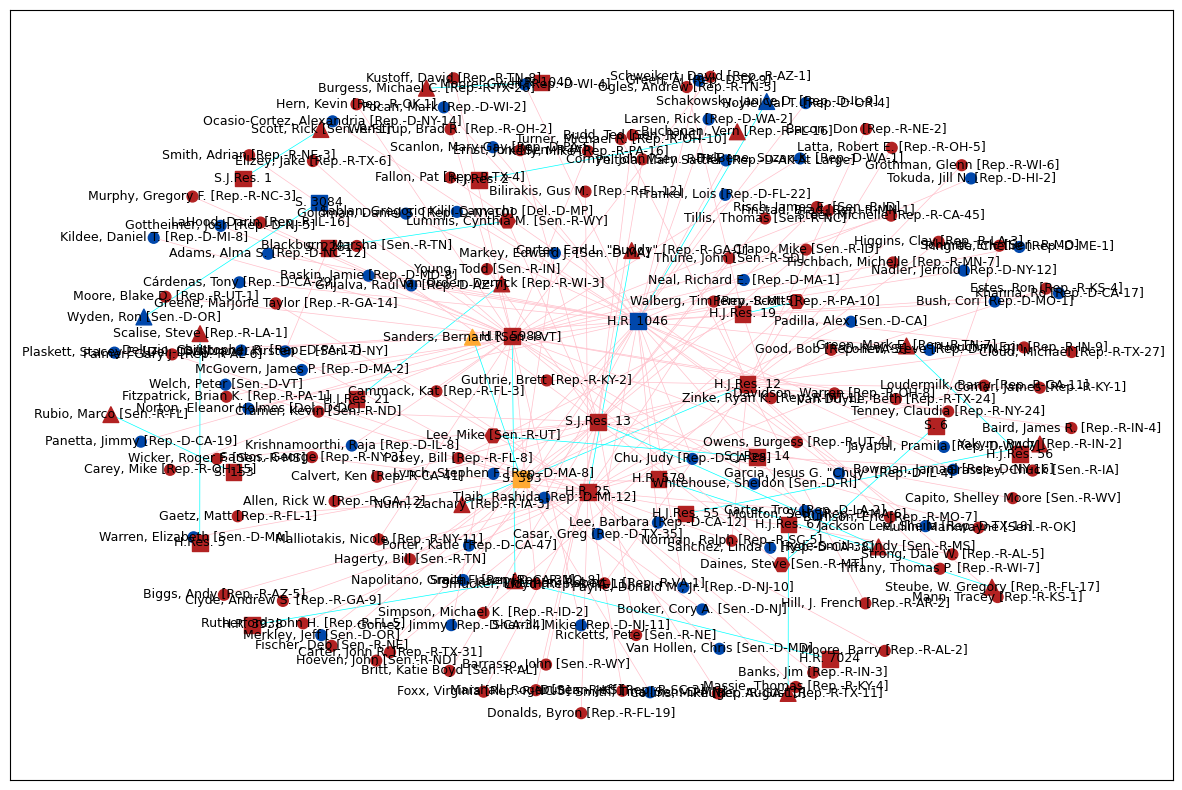

In [26]:
# chart networkx graph, just to check basic structure (this plot will be ugly)
## we'll make a prettier plot with Plotly, below.
## Get node labels from the 'label' attribute
labels = nx.get_node_attributes(G, 'label')

## Define node sizes based on node type, providing a default size if 'size' is missing
node_sizes = [G.nodes[node].get('size', 50) for node in G.nodes()]

## Calculate the layout
pos = nx.spring_layout(G, k=.5)  # Adjust 'k' for spacing

## Define node colors from node color attribute
node_colors = [G.nodes[node]['color']
               if 'color' in G.nodes[node]
               else 'gray' for node in G.nodes()]

## Define node shapes
node_shapes = nx.get_node_attributes(G, 'shape') # dictionary of node:shape

## Define edge colors
edge_colors = [G.edges[edge]['color']
               if 'color' in G.edges[edge]
               else 'gray' for edge in G.edges()]

## Draw the graph
plt.figure(figsize=(15,10))

### Create separate lists of nodes by shape
o_nodes = [node for node, shape in node_shapes.items() if shape == 'o']
s_nodes = [node for node, shape in node_shapes.items() if shape == 's']
t_nodes = [node for node, shape in node_shapes.items() if shape == '^']
h_nodes = [node for node, shape in node_shapes.items() if shape == 'H']

## Draw each shape type separately
draw_netx_nodes(o_nodes, 'o')
draw_netx_nodes(s_nodes, 's')
draw_netx_nodes(t_nodes, '^')
draw_netx_nodes(h_nodes, 'H')

nx.draw_networkx_edges(G, pos, edge_color=edge_colors, width=0.5) # Draw edges separately
nx.draw_networkx_labels(G, pos, labels, font_size=9) # Draw labels separately

plt.show()

In [27]:
# export edges to csv
G_edges = nx.to_pandas_edgelist(G)
edge_csv_path = os.path.join(out_dir, 'G_edges.csv')
G_edges.to_csv(edge_csv_path, index=False)

In [28]:
# export nodes to csv
G_nodes = pd.DataFrame(list(G.nodes(data=True)), columns=['node', 'attributes'])
for i, row in G_nodes.iterrows():
    for key, value in row['attributes'].items():
        G_nodes.at[i, key] = value
G_nodes.drop(columns=['attributes'], inplace=True)
node_csv_path = os.path.join(out_dir, 'G_nodes.csv')
G_nodes.to_csv(node_csv_path, index=False)

In [29]:
# retrieve nodes and edges from CSV
# so you don't have to run all the previous code again to create a readable Plotly network diagram
node_path = os.path.join(out_dir, 'G_nodes.csv')
edge_path = os.path.join(out_dir, 'G_edges.csv')

nodes_df = pd.read_csv(node_path, keep_default_na=False)
nodes_df

,node,label,sponsor,party,node_type,size,color,shape,sponsored,cosponsored
0,1,H.J.Res. 12,"Nunn, Zachary [Rep.-R-IA-3]",R,bill,128.0,#B22222,s,NA,NA
1,2,H.J.Res. 19,"Perry, Scott [Rep.-R-PA-10]",R,bill,128.0,#B22222,s,NA,NA
2,3,H.J.Res. 2,"Buchanan, Vern [Rep.-R-FL-16]",R,bill,128.0,#B22222,s,NA,NA
3,4,H.J.Res. 21,"Van Orden, Derrick [Rep.-R-WI-3]",R,bill,128.0,#B22222,s,NA,NA
4,5,H.J.Res. 55,"Yakym, Rudy [Rep.-R-IN-2]",R,bill,128.0,#B22222,s,NA,NA
...,...,...,...,...,...,...,...,...,...,...
185,186,"Whitehouse, Sheldon [Sen.-D-RI]",NA,D,cosponsor,60.0,#0047AB,o,NA,S. 393
186,187,"Wicker, Roger F. [Sen.-R-MS]",NA,R,cosponsor,60.0,#B22222,o,NA,S.J.Res. 13
187,188,"Wittman, Robert J. [Rep.-R-VA-1]",NA,R,cosponsor,60.0,#B22222,o,NA,H.J.Res. 12
188,189,"Young, Todd [Sen.-R-IN]",NA,R,cosponsor,60.0,#B22222,o,NA,S.J.Res. 13


In [30]:
# Create a new graph
Gfinal = nx.Graph()

# Open the nodes CSV file
with open(node_path, 'r') as f:
    reader = csv.reader(f)
    next(reader) # Skip the header row if it exists

    # Add nodes to the graph
    for row in reader:
        node_id = row[0] # Assuming the first column in the CSV is the node ID
        Gfinal.add_node(node_id)
        nx.set_node_attributes(Gfinal, {node_id: {'label': row[1],
                                                  'sponsor': row[2],
                                                  'party': row[3],
                                                  'type': row[4],
                                                  'size': row[5],
                                                  'color': row[6],
                                                  'shape': row[7],
                                                  'sponsored': row[8],
                                                  'cosponsored': row[9]}})

# Print the nodes in the graph
print(Gfinal.nodes(data=True))

# Open the eges CSV file
with open(edge_path, 'r') as f:
    reader = csv.reader(f)
    next(reader) # Skip the header row if it exists

    for row in reader:
      Gfinal.add_edge(row[0], row[1], color=row[2])

# Print the nodes in the graph
print(Gfinal.edges(data=True))

[('1', {'label': 'H.J.Res. 12', 'sponsor': 'Nunn, Zachary [Rep.-R-IA-3]', 'party': 'R', 'type': 'bill', 'size': '128.0', 'color': '#B22222', 'shape': 's', 'sponsored': 'NA', 'cosponsored': 'NA'}), ('2', {'label': 'H.J.Res. 19', 'sponsor': 'Perry, Scott [Rep.-R-PA-10]', 'party': 'R', 'type': 'bill', 'size': '128.0', 'color': '#B22222', 'shape': 's', 'sponsored': 'NA', 'cosponsored': 'NA'}), ('3', {'label': 'H.J.Res. 2', 'sponsor': 'Buchanan, Vern [Rep.-R-FL-16]', 'party': 'R', 'type': 'bill', 'size': '128.0', 'color': '#B22222', 'shape': 's', 'sponsored': 'NA', 'cosponsored': 'NA'}), ('4', {'label': 'H.J.Res. 21', 'sponsor': 'Van Orden, Derrick [Rep.-R-WI-3]', 'party': 'R', 'type': 'bill', 'size': '128.0', 'color': '#B22222', 'shape': 's', 'sponsored': 'NA', 'cosponsored': 'NA'}), ('5', {'label': 'H.J.Res. 55', 'sponsor': 'Yakym, Rudy [Rep.-R-IN-2]', 'party': 'R', 'type': 'bill', 'size': '128.0', 'color': '#B22222', 'shape': 's', 'sponsored': 'NA', 'cosponsored': 'NA'}), ('6', {'label':

In [31]:
# Plotly code adapted from 'https://plotly.com/python/network-graphs/'
# calculate node positions using spring_layout
pos = nx.spring_layout(Gfinal, k=0.15, iterations=20)

# add node positions to the graph
nx.set_node_attributes(Gfinal, pos, 'pos')

# add edges as disconnected lines in a single trace and nodes as a scatter trace
edge_x = []
edge_y = []
for edge in Gfinal.edges():
    x0, y0 = Gfinal.nodes[edge[0]]['pos']
    x1, y1 = Gfinal.nodes[edge[1]]['pos']
    edge_x.append(x0)
    edge_x.append(x1)
    edge_x.append(None)
    edge_y.append(y0)
    edge_y.append(y1)
    edge_y.append(None)

edge_trace = go.Scatter(
    x=edge_x, y=edge_y,
    name="Edges",
    line=dict(width=0.5, color='#888'),
    hoverinfo='none',
    showlegend=False,
    mode='lines')

node_x = []
node_y = []
for node in Gfinal.nodes():
    x, y = Gfinal.nodes[node]['pos']
    node_x.append(x)
    node_y.append(y)

hover_text = [] # create empty list to store hover text
included_attributes = ["label",
                       "sponsor",
                       "sponsored",
                       "cosponsored"]  # list of node attributes to include in hover text

for node in Gfinal.nodes():
    attributes = Gfinal.nodes[node]
    text = f""
    for attr_name, attr_value in attributes.items():
        if attr_name in included_attributes:
          if attr_value != "NA":
            text += f"{attr_name}: {attr_value}<br>"
    hover_text.append(text)

node_trace = go.Scatter(
    x=node_x, y=node_y,
    name='Nodes',
    mode='markers',
    hoverinfo='text',
    text=hover_text,
    showlegend=False,
    marker=dict(
        color=[str(c) for c in nx.get_node_attributes(Gfinal, 'color').values()],
        size=[float(s)/4 for s in nx.get_node_attributes(Gfinal, 'size').values()],
        symbol=['square' if s == 's'
                else ('circle' if s == 'o' else 'triangle-down' if s == '^' else 'hexagon')
                for s in nx.get_node_attributes(Gfinal, 'shape').values()],
        line=dict(width=1, color='black'),
        showscale=False),
)

In [32]:
# Plotly code adapted from 'https://plotly.com/python/network-graphs/'
# create initial Plotly diagram
fig = go.Figure(data=[edge_trace, node_trace],
             layout=go.Layout(
                title=dict(
                    text=chart_title,
                    font=dict(
                        size=16
                    )
                ),
                hovermode='closest',
                margin=dict(b=20,l=10,r=0,t=55),
                xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
                yaxis=dict(showgrid=False, zeroline=False, showticklabels=False))
                )
fig.update_layout(width=1000, height=800, plot_bgcolor='#F1F1F1')

In [33]:
# get a list of unique node colors for legend
unique_colors = set(nx.get_node_attributes(Gfinal, 'color').values())

# map the colors to the parties
color_map = {'#0047AB': 'Democrat', '#FFAA33': 'Independent', '#B22222': 'Republican'}

# create separate traces for each legend item
for color in unique_colors:
    color_legend_trace = go.Scatter(
        x=[None],
        y=[None],
        mode='markers',
        marker=dict(
            color=color,
            size=15,
            symbol='circle'  # Use circle for all legend items
        ),
        name=color_map.get(color, "Unknown"),  # Single party name
        showlegend=True
    )
    fig.add_trace(color_legend_trace)  # Add each legend trace separately

# add legend to chart
fig.update_layout(
    legend=dict(
        x=1.05,
        y=1.0,
        title="Node Legend",
        traceorder="normal",
        bgcolor="rgba(255, 255, 255, 0.8)",
        bordercolor="black",
        borderwidth=1,
        orientation="v",
        itemclick=False,
        font=dict(size=10)
    )
)

In [34]:
# get a list of unique node shapes for shape legend
unique_shapes = set(nx.get_node_attributes(Gfinal, 'shape').values())

# map the shapes to the node types
shape_map = {'s': 'Bill', 'o': 'Cosponsor', '^': 'Sponsor', 'H': 'Sponsor/Cosponsor'}

# map the shapes to the plotly symbol values
plotly_shape_map = {'s': 'square', 'o': 'circle', '^': 'triangle-down', 'H': 'hexagon'}

# Create separate traces for each legend item
for shape in unique_shapes:
    # Get the Plotly symbol value, defaulting to 'circle' if not found in the map
    plotly_symbol = plotly_shape_map.get(shape, 'circle')

    shape_legend_trace = go.Scatter(
        x=[None],
        y=[None],
        mode='markers',
        marker=dict(
            color='white',  # Use black for all legend items
            size=15,
            symbol=plotly_symbol, # Use the mapped or default symbol
            line=dict(width=1, color='black')
        ),
        name=shape_map.get(shape, "Unknown"),
        showlegend=True
    )
    fig.add_trace(shape_legend_trace)  # Add each legend trace separately

# update legend to incude shapes
fig.update_layout(
    legend=dict(
        x=1.05,
        y=.75,
        title="Node Legend",
        traceorder="normal",
        bgcolor="rgba(255, 255, 255, 0.8)",
        bordercolor="black",
        borderwidth=1,
        orientation="v",
        itemclick=False,
        font=dict(size=10)
    )
)

In [35]:
# set path for html output
html_path = os.path.join(out_dir, 'network.html')

# write interactive plot to html
fig.write_html(html_path)